In [1]:
import os 
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
import xml.etree.ElementTree as ET

In [2]:
image_dir=r"C:\Users\helna\Downloads\archive_mask\images"
annotation_dir=r"C:\Users\helna\Downloads\archive_mask\annotations"
output_dir=r"C:\Users\helna\Downloads\archive_mask"

classes=['with_mask','without_mask','mask_weared_incorrect']

In [3]:
for cls in classes:
    os.makedirs(os.path.join(output_dir,'train',cls),exist_ok=True)
    os.makedirs(os.path.join(output_dir,'val',cls),exist_ok=True)


In [4]:
def process_annotations_xml():
    created_any=False
    for xml_file in os.listdir(annotation_dir):
        if not xml_file.endswith('.xml'):
            continue

        xml_path = os.path.join(annotation_dir,xml_file)
        tree = ET.parse(xml_path)
        root = tree.getroot()


        img_name = root.find('filename').text
        img_path = os.path.join(image_dir,img_name)


        img = cv2.imread(img_path)
        if img is None:
            print(f" Couldn't read image: {img_path}")
            continue

        for obj in root.findall('object'):
            label = obj.find('name').text
            if label not in classes:
                print(f" Unknown label {label} in {xml_file}")
                continue

            bndbox = obj.find('bndbox')
            x1 = int(bndbox.find('xmin').text)
            y1 = int(bndbox.find('ymin').text)
            x2 = int(bndbox.find('xmax').text)
            y2 = int(bndbox.find('ymax').text)

            face = img[y1:y2,x1:x2]
            if face.size == 0:
                print(f"Empty crop in {img_name}")
                continue

            save_path = os.path.join(output_dir,'all',label,img_name)
            os.makedirs(os.path.dirname(save_path), exist_ok = True)
            cv2.imwrite(save_path, face)
            print(f" saved:{save_path}")
            created_any = True

    if not created_any:
        print("No images were saved.Check your annotations or images.")

process_annotations_xml()
for cls in classes:
    img_list = os.listdir(os.path.join(output_dir,'all',cls))
    train_imgs,val_imgs = train_test_split(img_list,test_size=0.2,random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(output_dir,'all',cls,img),os.path.join(output_dir,'train',cls,img))
    print(os.path.join(output_dir,'all',cls))
    print(os.path.exists(os.path.join(output_dir,'all',cls)))
        
    for img in val_imgs:
        shutil.copy(os.path.join(output_dir, 'all', cls, img), os.path.join(output_dir, 'val', cls, img))
                                    

 saved:C:\Users\helna\Downloads\archive_mask\all\without_mask\maksssksksss0.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss0.png
 saved:C:\Users\helna\Downloads\archive_mask\all\without_mask\maksssksksss0.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\without_mask\maksssksksss1.png
 saved:C:\Users\helna\Downloads\archive_mask\all\with_mask\maksssks

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [6]:
image_size = (128,128)
batch_size =32

In [7]:
train_dir = os.path.join(output_dir,'train')
val_dir = os.path.join(output_dir,'val')

train_datagen=ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 919 images belonging to 3 classes.
Found 232 images belonging to 3 classes.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten, Dense,Dropout
from tensorflow.keras.optimizers import Adam

In [9]:
model=Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(0.5),
    Dense(train_generator.num_classes,activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
history=model.fit(train_generator,validation_data=val_generator,epochs=10)

Epoch 1/10
29/29 [==============================] - 28s 860ms/step - loss: 1.0986 - accuracy: 0.0838 - val_loss: 1.0986 - val_accuracy: 0.0862
Epoch 2/10
29/29 [==============================] - 22s 743ms/step - loss: 1.0986 - accuracy: 0.0838 - val_loss: 1.0986 - val_accuracy: 0.0862
Epoch 3/10
29/29 [==============================] - 17s 571ms/step - loss: 1.0986 - accuracy: 0.0838 - val_loss: 1.0986 - val_accuracy: 0.0862
Epoch 4/10
29/29 [==============================] - 13s 458ms/step - loss: 1.0986 - accuracy: 0.0838 - val_loss: 1.0986 - val_accuracy: 0.0862
Epoch 5/10
29/29 [==============================] - 15s 507ms/step - loss: 1.0986 - accuracy: 0.0838 - val_loss: 1.0986 - val_accuracy: 0.0862
Epoch 6/10
29/29 [==============================] - 15s 512ms/step - loss: 1.0986 - accuracy: 0.0838 - val_loss: 1.0986 - val_accuracy: 0.0862
Epoch 7/10
29/29 [==============================] - 16s 560ms/step - loss: 1.0986 - accuracy: 0.0838 - val_loss: 1.0986 - val_accuracy: 0.0862

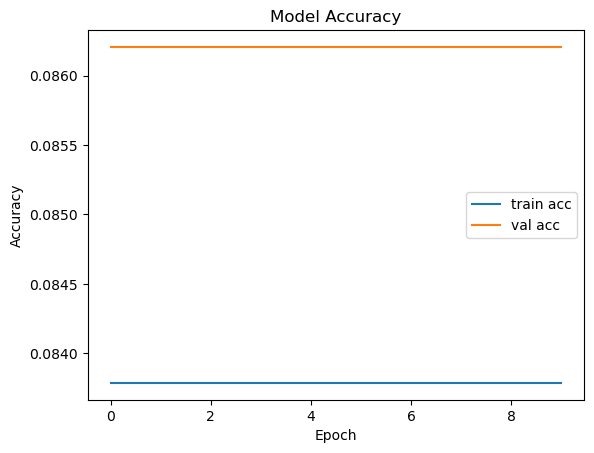

In [11]:


import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='train acc')
plt.plot(history.history['val_accuracy'],label='val acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
model.save('face_mask_model.h5')
print("Model saved as 'face_mask_model.h5'")

Model saved as 'face_mask_model.h5'


C:\Users\helna\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [13]:
#predict

In [14]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array,load_img

In [15]:
model=load_model('face_mask_model.h5')

In [16]:
classes=['with_mask','without_mask','mask_weared,incorrect']

In [17]:
img_path = r"C:\Users\helna\Downloads\archive_mask\train\with_mask\maksssksksss71.png"
img = load_img(img_path,target_size=(128,128))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)/255.0

In [18]:
pred = model.predict(img_array)
class_index = np.argmax(pred)
print(f"Prediction: {classes[class_index]} (confidence: {pred[0][class_index]:.2f})")

1/1 [==============================] - 0s 279ms/step
Prediction: with_mask (confidence: 0.33)


In [ ]:
import cv2
from tensorflow.keras.models import load_model
import numpy as np

model = load_model('face_mask_model.h5')
classes = ['with_mask', 'without_mask']

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

cap = cv2.VideoCapture(0)

while True:
    ret,frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor = 1.1, minNeighbors = 4)

    for (x, y, w, h) in faces:
        face_img = frame[y:y+h, x:x+w]
        face_resized = cv2.resize(face_img, (128,128))
        face_array = np.expand_dims(face_resized / 255.0, axis = 0)

        prediction = model.predict(face_array)
        class_idx=np.argmax(prediction)
        label = f"{classes[class_idx]} ({prediction[0][class_idx]*100:.1f}%)"

        color = (0, 255, 0) if class_idx == 0 else(0,0,255)
        cv2.rectangle(frame, (x,y), (x+w,y+h), color,2)
        cv2.putText(frame, label,(x,y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color,2)

    cv2.imshow('Face Mask Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.deatroyAllWindows()

1/1 [==============================] - 0s 31ms/step


model=load_model('face_mask_model.h5')
classes = ['with_mask','without_mask']
face_cascade=cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontal